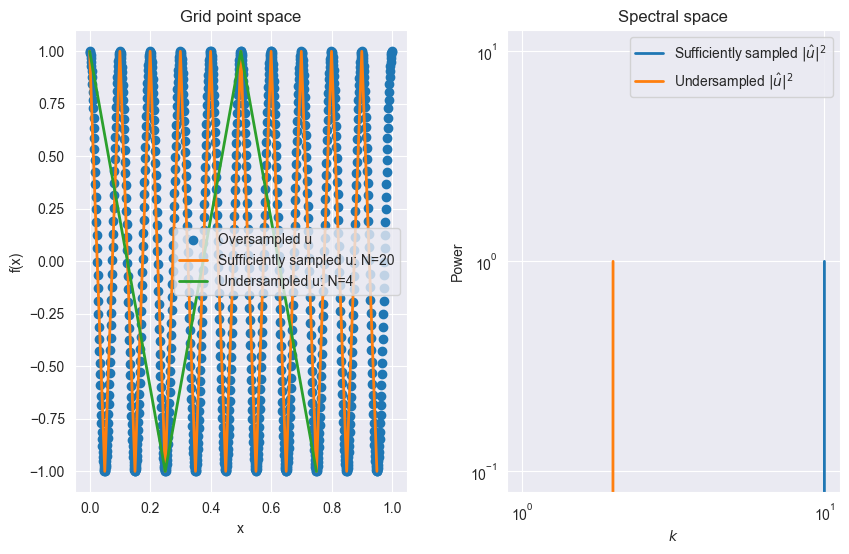

In [4]:
import numpy as np
import scipy.fft as ft
import matplotlib.pyplot as plt

pi = np.pi
L = 1
N = 20
N1 = 4

y = np.linspace(0, L, 1000)
x = np.linspace(0, L, N, endpoint=False)
x1 = np.linspace(0, L, N1, endpoint=False)

u1 = np.cos(2 * 10 * pi * y / L)
u = np.cos(2 * 10 * pi * x / L)
v = np.cos(2 * 10 * pi * x1 / L)

vhat = ft.rfft(v, norm="forward")
uhat = ft.rfft(u, norm="forward")

u2 = uhat * np.conj(uhat)
v2 = vhat * np.conj(vhat)

fig = plt.figure(figsize=(9, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(y, u1, "o", label="Oversampled u")
ax1.plot(x, u, label=f"Sufficiently sampled u: N={N}", linewidth=2)
ax1.plot(x1, v, label=f"Undersampled u: N={N1}", linewidth=2)
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.set_title("Grid point space")
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
k = np.arange(len(uhat))
k1 = np.arange(len(vhat))

ax2.loglog(k[1:], u2[1:], label="Sufficiently sampled $|\\hat u|^2$", linewidth=2)
ax2.loglog(k1[1:], v2[1:], label="Undersampled $|\\hat u|^2$", linewidth=2)
ax2.set_xlabel("$k$")
ax2.set_ylabel("Power")
ax2.set_title("Spectral space")
ax2.legend()

plt.subplots_adjust(left=0.12, right=0.97, wspace=0.3)
plt.show()


In [3]:
uhat

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 1.+0.j])

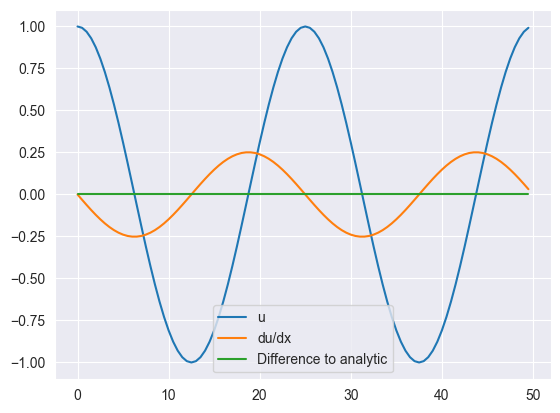

In [5]:
from scipy.fftpack import diff as psdiff

L=50; N=100; pi=np.pi

x = np.linspace(0,L,N, endpoint=False)
u = np.cos(2*pi*x/25)
uxan = -2*pi/25*np.sin(2*pi*x/25)
ux = psdiff(u, period=L)
plt.plot(x,u, label="u")
plt.plot(x,ux, label="du/dx")
plt.plot(x,uxan-ux,label="Difference to analytic")
plt.legend()